In [1]:
#Libraries and Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    fcluster
)

from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster


In [2]:
#Load Dataset
df_pca = pd.read_csv("pca_dataset.csv")

PC = df_pca.drop(
    columns=["target_actual"]
)

In [3]:
#linkage Matrix
Z = linkage(
    PC,
    method="ward"
)

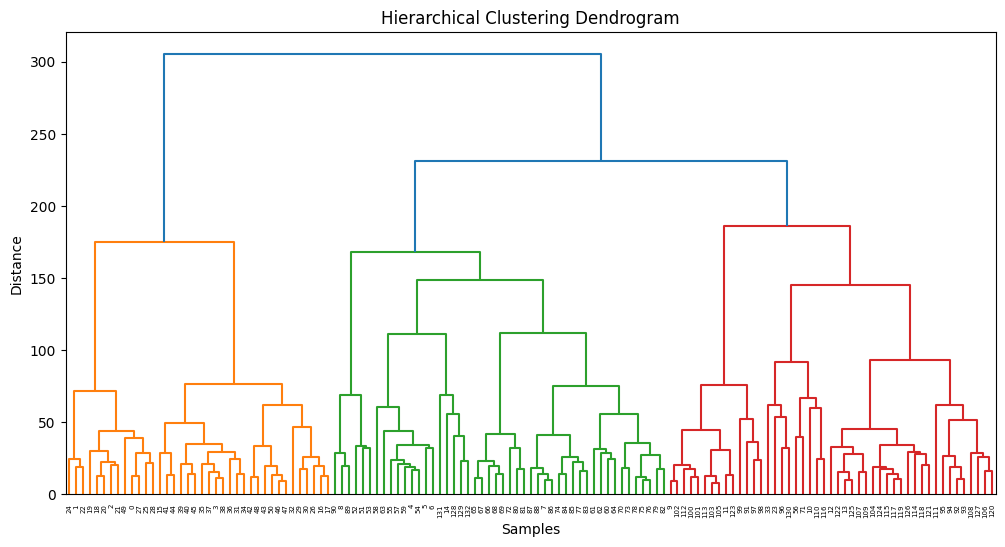

In [5]:
#Dendogram Visualization
plt.figure(figsize=(12,6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.savefig(
    "screenshots/Dendogram",
    dpi=300,
    bbox_inches="tight"
    )

plt.show()

In [6]:
#Silhouette Score
scores = {}

for k in range(2,11):

    labels = fcluster(
        Z,
        k,
        criterion="maxclust"
    )

    scores[k] = silhouette_score(
        PC,
        labels
    )

scores

{2: 0.20831936161337422,
 3: 0.22593985264226074,
 4: 0.20575342494397794,
 5: 0.20221466488924913,
 6: 0.23139758926416276,
 7: 0.24439464511467504,
 8: 0.25753569641742474,
 9: 0.24678257569142115,
 10: 0.2605816239342253}

In [7]:
hc_labels = fcluster(
    Z,
    2,
    criterion="maxclust"
)

df_pca["HC_Clusters"] = hc_labels

In [8]:
pd.crosstab(
    df_pca["target_actual"],
    df_pca["HC_Clusters"]
)

HC_Clusters,1,2
target_actual,,
normal breast tissue,0,11
primary breast cancer,38,84


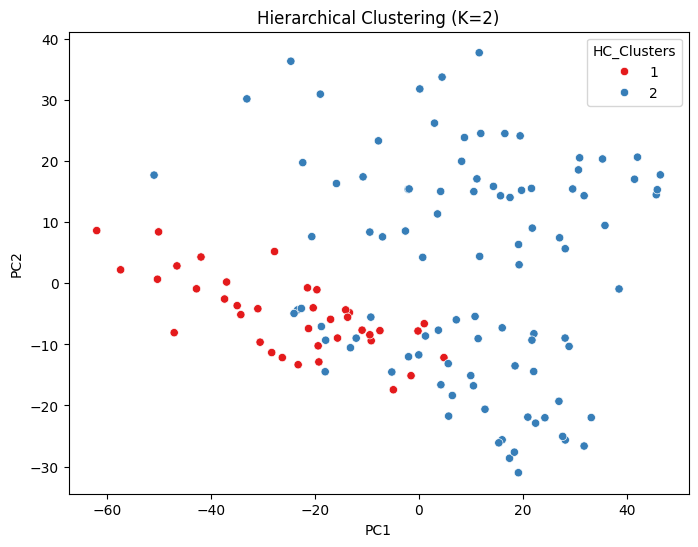

In [10]:
#PCA scatter plot for k = 2
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="HC_Clusters",
    palette="Set1"
)

plt.title("Hierarchical Clustering (K=2)")
plt.savefig(
    "screenshots/HC cluster visualization(k =2)",
    dpi=300,
    bbox_inches="tight"
    )
plt.show()

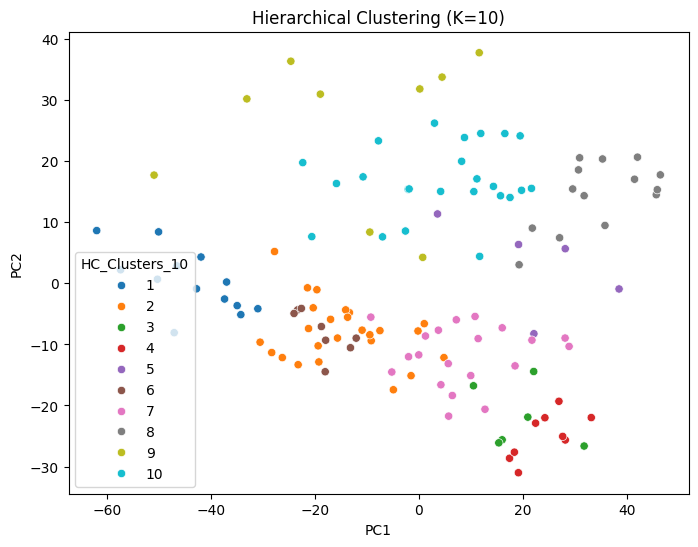

In [12]:
#Best Hierarchical clustering
hc_labels_10 = fcluster(
    Z,
    10,
    criterion="maxclust"
)

df_pca["HC_Clusters_10"] = hc_labels_10

#Visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="HC_Clusters_10",
    palette="tab10"
)

plt.title("Hierarchical Clustering (K=10)")
plt.savefig(
    "screenshots/Best HC cluster visualization(k=10)",
    dpi=300,
    bbox_inches="tight"
    )
plt.show()

In [13]:
df_pca["HC_Clusters_10"].value_counts().sort_index()

HC_Clusters_10
1     13
2     25
3      6
4      9
5      5
6      8
7     20
8     14
9      9
10    24
Name: count, dtype: int64